# TransFit Physical Regression and Convergence Checks

This notebook contains two executable checks for the physical model layer:

1. A frozen benchmark regression over bolometric summary quantities for the public models.
2. One-axis grid-sensitivity checks around the baseline `Nx=100, Ny=1000`: fixed `Nx` while varying `Ny`, and fixed `Ny` while varying `Nx`.

The benchmark values below are generated from the current TransFit implementation at the stated baseline grid. They are intended as a guardrail against accidental changes. If tabulated paper values or digitized figure values become available, replace `REFERENCE_SUMMARY` with those values and adjust the tolerances.


In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt

# Make the notebook runnable from either the repo root or examples/.
cwd = Path.cwd().resolve()
repo_root = cwd if (cwd / "transfit").exists() else cwd.parent
if (repo_root / "transfit").exists() and str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import transfit as tf

print("Using transfit from:", Path(tf.__file__).resolve())

Using transfit from: C:\Users\zyh\Desktop\TransFit\transfit\__init__.py


In [2]:
MODEL_CASES = {
    "nickel": {
        "params": {
            "M_ej": 3.0,
            "v_ej": 1.0,
            "E_Th_in": 1.5,
            "M_ni": 0.08,
            "R_0": 120.0,
            "f_ni": 0.2,
            "kappa": 0.12,
            "kappa_gamma": 0.03,
            "T_floor": 3000.0,
        },
        "t_max_days": 120.0,
    },
    "magnetar": {
        "params": {
            "M_ej": 5.0,
            "v_ej": 1.2,
            "E_Th_in": 1.0,
            "P_ms": 4.0,
            "B14": 1.5,
            "f_mag": 0.2,
            "R_0": 80.0,
            "kappa": 0.12,
            "kappa_gamma": 0.03,
            "T_floor": 3000.0,
        },
        "t_max_days": 120.0,
    },
    "magnetar_ni": {
        "params": {
            "M_ej": 5.0,
            "v_ej": 1.2,
            "P_ms": 4.0,
            "B14": 1.5,
            "f_mag": 0.2,
            "M_ni": 0.08,
            "f_ni": 0.05,
            "kappa": 0.12,
            "kappa_gamma": 0.03,
            "T_floor": 3000.0,
        },
        "t_max_days": 120.0,
    },
}

REFERENCE_GRID = {"Nx": 100, "Ny": 1000}
SUMMARY_TIMES_DAYS = np.array([10.0, 30.0, 60.0, 100.0], dtype=float)


def summarize_bolometric_case(model: str, cfg: dict, *, Nx: int, Ny: int) -> dict[str, float]:
    params = cfg["params"]
    t_max_days = float(cfg["t_max_days"])
    lc = tf.lightcurve_bol(
        model=model,
        params=params,
        solver_kwargs={"Nx": Nx, "Ny": Ny},
        t_max_days=t_max_days,
    )
    peak_idx = int(np.nanargmax(lc.Lbol))
    sampled = tf.predict_bol(
        model=model,
        params=params,
        t_days=SUMMARY_TIMES_DAYS,
        solver_kwargs={"Nx": Nx, "Ny": Ny},
        t_max_days=t_max_days,
        interp_fill="nan",
    )
    return {
        "t_peak_days": float(lc.t_days[peak_idx]),
        "log10_L_peak": float(np.log10(lc.Lbol[peak_idx])),
        "log10_L_10d": float(np.log10(sampled[0])),
        "log10_L_30d": float(np.log10(sampled[1])),
        "log10_L_60d": float(np.log10(sampled[2])),
        "log10_L_100d": float(np.log10(sampled[3])),
        "Teff_peak_K": float(lc.Teff[peak_idx]),
        "Rph_peak_cm": float(lc.Rph[peak_idx]),
    }

## 1. Frozen Physical Summary Regression

This check locks a small set of physically interpretable summary quantities: peak time, peak luminosity, luminosities at representative epochs, and photospheric state at peak. The tolerances are deliberately tight enough to catch accidental model changes while allowing minor floating-point/platform differences.

In [3]:
REFERENCE_SUMMARY = {
    "nickel": {
        "t_peak_days": 0.1200000023681568,
        "log10_L_peak": 42.14387819067064,
        "log10_L_10d": 40.76068300687874,
        "log10_L_30d": 42.04308210581813,
        "log10_L_60d": 41.714282637956,
        "log10_L_100d": 41.29523730811871,
        "Teff_peak_K": 45098.81722424167,
        "Rph_peak_cm": 21737030708634.9,
    },
    "magnetar": {
        "t_peak_days": 33.480000721,
        "log10_L_peak": 44.02326876078898,
        "log10_L_10d": 40.8683087609086,
        "log10_L_30d": 44.00941152539804,
        "log10_L_60d": 43.73971980560872,
        "log10_L_100d": 43.17349796757802,
        "Teff_peak_K": 9260.636900788852,
        "Rph_peak_cm": 4486876289320030.0,
    },
    "magnetar_ni": {
        "t_peak_days": 33.480000721,
        "log10_L_peak": 44.02564964548707,
        "log10_L_10d": 40.73869756380814,
        "log10_L_30d": 44.01148721871176,
        "log10_L_60d": 43.74318279636271,
        "log10_L_100d": 43.1785818101671,
        "Teff_peak_K": 9279.024933632245,
        "Rph_peak_cm": 4481377889320030.0,
    },
}

ABS_TOL = {
    "t_peak_days": 0.25,
    "log10_L_peak": 0.025,
    "log10_L_10d": 0.025,
    "log10_L_30d": 0.025,
    "log10_L_60d": 0.025,
    "log10_L_100d": 0.025,
}
REL_TOL = {
    "Teff_peak_K": 0.05,
    "Rph_peak_cm": 0.05,
}

regression_report = {}
for model, cfg in MODEL_CASES.items():
    got = summarize_bolometric_case(model, cfg, **REFERENCE_GRID)
    expected = REFERENCE_SUMMARY[model]
    regression_report[model] = got
    for key, expected_value in expected.items():
        got_value = got[key]
        if key in ABS_TOL:
            diff = abs(got_value - expected_value)
            assert diff <= ABS_TOL[key], f"{model}.{key}: got {got_value}, expected {expected_value}, diff {diff}"
        else:
            rel = abs(got_value - expected_value) / max(abs(expected_value), 1e-300)
            assert rel <= REL_TOL[key], f"{model}.{key}: got {got_value}, expected {expected_value}, rel {rel}"

print("Physical summary regression passed.")
regression_report

Physical summary regression passed.


{'nickel': {'t_peak_days': 0.12000000236815683,
  'log10_L_peak': 42.14387819067064,
  'log10_L_10d': 40.76068300687874,
  'log10_L_30d': 42.04308210581813,
  'log10_L_60d': 41.714282637956,
  'log10_L_100d': 41.29523730811871,
  'Teff_peak_K': 45098.81722424167,
  'Rph_peak_cm': 21737030708634.9},
 'magnetar': {'t_peak_days': 33.480000721,
  'log10_L_peak': 44.02326876078898,
  'log10_L_10d': 40.8683087609086,
  'log10_L_30d': 44.00941152539804,
  'log10_L_60d': 43.73971980560872,
  'log10_L_100d': 43.17349796757802,
  'Teff_peak_K': 9260.636900788852,
  'Rph_peak_cm': 4486876289320030.0},
 'magnetar_ni': {'t_peak_days': 33.480000721,
  'log10_L_peak': 44.02564964548707,
  'log10_L_10d': 40.73869756380814,
  'log10_L_30d': 44.01148721871176,
  'log10_L_60d': 43.74318279636271,
  'log10_L_100d': 43.1785818101671,
  'Teff_peak_K': 9279.024933632245,
  'Rph_peak_cm': 4481377889320030.0}}

## 2. One-Axis Grid-Sensitivity Checks

The baseline grid is `Nx=100, Ny=1000`. The two checks below isolate the grid directions:

- fixed `Nx=100`, varying `Ny`;
- fixed `Ny=1000`, varying `Nx`.

Each curve is compared against the baseline curve over 10 to 100 observer-frame days. This is a practical sensitivity check rather than a formal proof of convergence; the plots in the next section show the full behavior by eye.


In [4]:
BASELINE_GRID = (100, 1000)
FIXED_NX_SWEEP_GRIDS = [
    (100, 500),
    (100, 1000),
    (100, 2000),
]
FIXED_NY_SWEEP_GRIDS = [
    (50, 1000),
    (100, 1000),
    (200, 1000),
    (400, 1000),
    (800, 1000),
    (1600, 1000),
]
CONVERGENCE_TIMES_DAYS = np.linspace(10.0, 100.0, 80)
MAX_FIXED_NX_LOG10_DIFF = 0.04
MAX_FIXED_NY_LOG10_DIFF = 0.25


def predict_on_grid(model: str, cfg: dict, grid: tuple[int, int]) -> np.ndarray:
    Nx, Ny = grid
    return tf.predict_bol(
        model=model,
        params=cfg["params"],
        t_days=CONVERGENCE_TIMES_DAYS,
        solver_kwargs={"Nx": Nx, "Ny": Ny},
        t_max_days=float(cfg["t_max_days"]),
        interp_fill="nan",
    )


def log10_diff(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    good = np.isfinite(a) & np.isfinite(b) & (a > 0.0) & (b > 0.0)
    out = np.full_like(a, np.nan, dtype=float)
    out[good] = np.abs(np.log10(a[good]) - np.log10(b[good]))
    return out


def grid_sweep_report(model: str, cfg: dict, grids: list[tuple[int, int]]) -> dict[str, dict[str, float]]:
    baseline = predict_on_grid(model, cfg, BASELINE_GRID)
    report = {}
    for grid in grids:
        curve = predict_on_grid(model, cfg, grid)
        diff = log10_diff(curve, baseline)
        report[f"Nx={grid[0]}, Ny={grid[1]}"] = {
            "max_log10_diff_vs_baseline": float(np.nanmax(diff)),
            "p95_log10_diff_vs_baseline": float(np.nanpercentile(diff, 95.0)),
        }
    return report


grid_sensitivity_report = {}
for model, cfg in MODEL_CASES.items():
    fixed_nx = grid_sweep_report(model, cfg, FIXED_NX_SWEEP_GRIDS)
    fixed_ny = grid_sweep_report(model, cfg, FIXED_NY_SWEEP_GRIDS)
    grid_sensitivity_report[model] = {
        "fixed_Nx_vary_Ny": fixed_nx,
        "fixed_Ny_vary_Nx": fixed_ny,
    }

    for grid_label, stats in fixed_nx.items():
        assert stats["max_log10_diff_vs_baseline"] <= MAX_FIXED_NX_LOG10_DIFF, (
            f"{model} fixed Nx / varying Ny: {grid_label} max diff "
            f"{stats['max_log10_diff_vs_baseline']} exceeds {MAX_FIXED_NX_LOG10_DIFF}"
        )
    for grid_label, stats in fixed_ny.items():
        assert stats["max_log10_diff_vs_baseline"] <= MAX_FIXED_NY_LOG10_DIFF, (
            f"{model} fixed Ny / varying Nx: {grid_label} max diff "
            f"{stats['max_log10_diff_vs_baseline']} exceeds {MAX_FIXED_NY_LOG10_DIFF}"
        )

print("One-axis grid-sensitivity checks passed.")
grid_sensitivity_report


One-axis grid-sensitivity checks passed.


{'nickel': {'fixed_Nx_vary_Ny': {'Nx=100, Ny=500': {'max_log10_diff_vs_baseline': 0.0012550488098455048,
    'p95_log10_diff_vs_baseline': 0.0002468133002789585},
   'Nx=100, Ny=1000': {'max_log10_diff_vs_baseline': 0.0,
    'p95_log10_diff_vs_baseline': 0.0},
   'Nx=100, Ny=2000': {'max_log10_diff_vs_baseline': 0.00032136079916966764,
    'p95_log10_diff_vs_baseline': 4.9332531546042426e-05}},
  'fixed_Ny_vary_Nx': {'Nx=50, Ny=1000': {'max_log10_diff_vs_baseline': 0.030418690441713636,
    'p95_log10_diff_vs_baseline': 0.030407710417652112},
   'Nx=100, Ny=1000': {'max_log10_diff_vs_baseline': 0.0,
    'p95_log10_diff_vs_baseline': 0.0},
   'Nx=200, Ny=1000': {'max_log10_diff_vs_baseline': 0.014636969003319678,
    'p95_log10_diff_vs_baseline': 0.014631306915270415},
   'Nx=400, Ny=1000': {'max_log10_diff_vs_baseline': 0.021820072499842524,
    'p95_log10_diff_vs_baseline': 0.021811537590989617},
   'Nx=800, Ny=1000': {'max_log10_diff_vs_baseline': 0.02537872324063528,
    'p95_log10_

## 3. Visual Light-Curve Diagnostics

The plots below make the two checks inspectable by eye. The first figure shows the baseline bolometric light curves and the sampled regression epochs. The next two figures are the requested one-axis grid sweeps: fixed `Nx=100` while varying `Ny`, and fixed `Ny=1000` while varying `Nx` out to `Nx=1600`. Each sweep includes light curves and the absolute log-luminosity difference relative to the baseline `Nx=100, Ny=1000` curve.


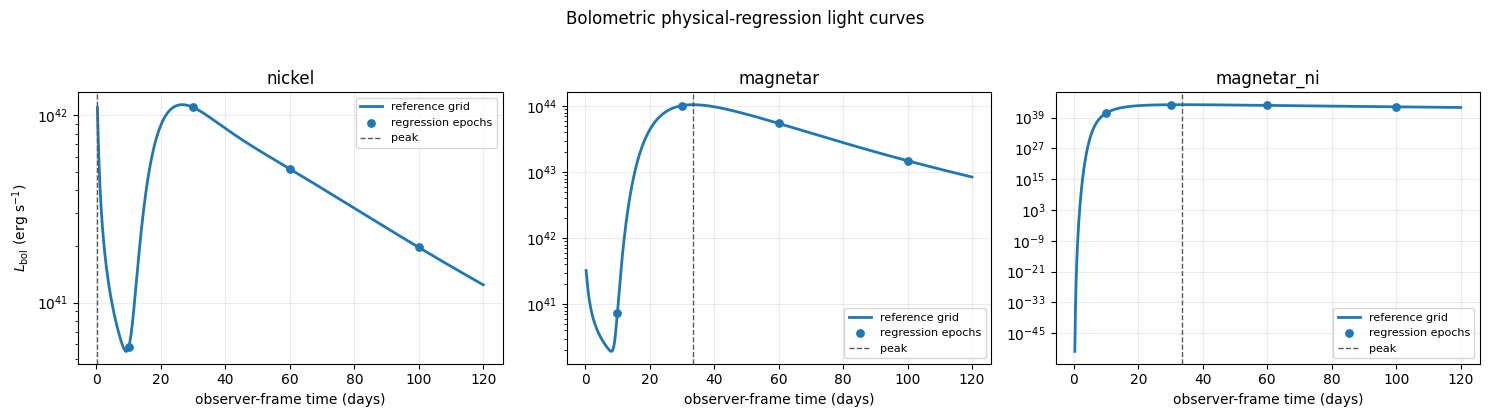

In [5]:
PLOT_GRID = REFERENCE_GRID
PLOT_TIMES_DAYS = np.linspace(0.1, 120.0, 600)

fig, axes = plt.subplots(1, len(MODEL_CASES), figsize=(15, 4), sharey=False)
if len(MODEL_CASES) == 1:
    axes = [axes]

for ax, (model, cfg) in zip(axes, MODEL_CASES.items()):
    y = tf.predict_bol(
        model=model,
        params=cfg["params"],
        t_days=PLOT_TIMES_DAYS,
        solver_kwargs={"Nx": PLOT_GRID["Nx"], "Ny": PLOT_GRID["Ny"]},
        t_max_days=float(cfg["t_max_days"]),
        interp_fill="nan",
    )
    summary = regression_report[model]
    sampled = tf.predict_bol(
        model=model,
        params=cfg["params"],
        t_days=SUMMARY_TIMES_DAYS,
        solver_kwargs={"Nx": PLOT_GRID["Nx"], "Ny": PLOT_GRID["Ny"]},
        t_max_days=float(cfg["t_max_days"]),
        interp_fill="nan",
    )
    ax.plot(PLOT_TIMES_DAYS, y, lw=2.0, label="reference grid")
    ax.scatter(SUMMARY_TIMES_DAYS, sampled, s=28, zorder=3, label="regression epochs")
    ax.axvline(summary["t_peak_days"], color="0.35", ls="--", lw=1.0, label="peak")
    ax.set_title(model)
    ax.set_xlabel("observer-frame time (days)")
    ax.set_yscale("log")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)

axes[0].set_ylabel(r"$L_{\rm bol}$ (erg s$^{-1}$)")
fig.suptitle("Bolometric physical-regression light curves", y=1.03)
fig.tight_layout()
plt.show()


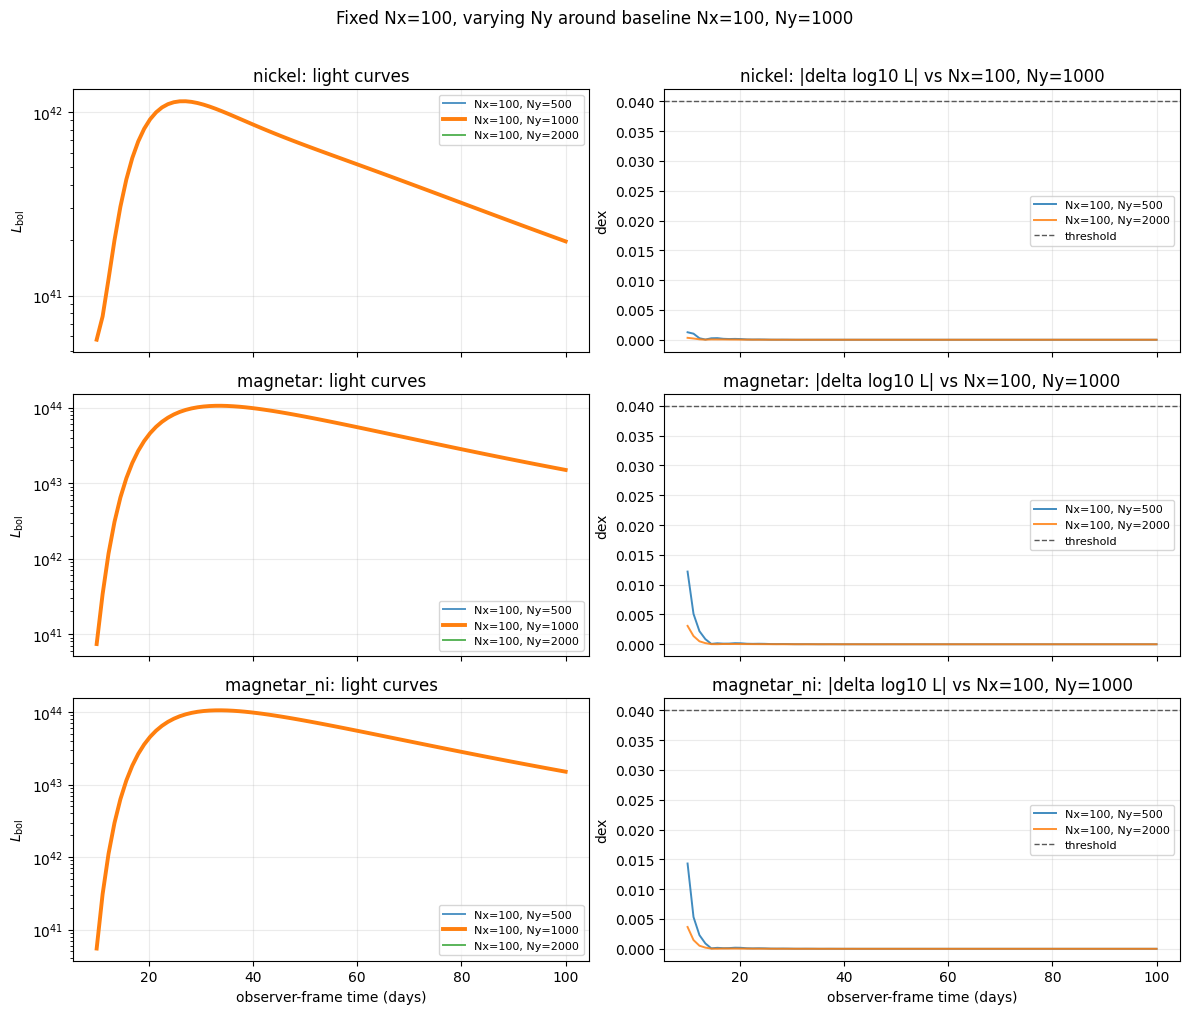

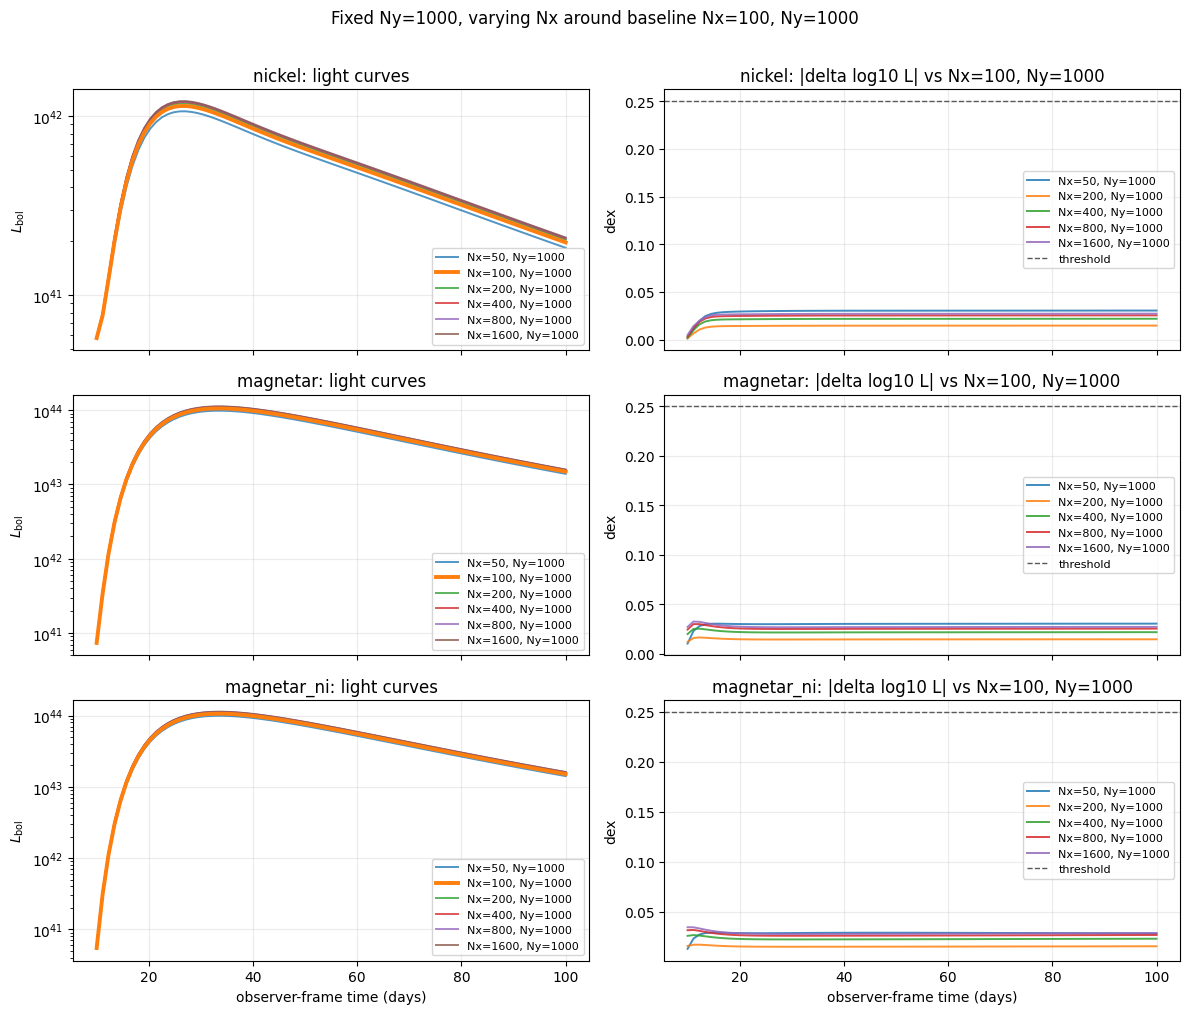

In [6]:
def plot_grid_sweep(
    *,
    title: str,
    grids: list[tuple[int, int]],
    threshold: float,
) -> None:
    fig, axes = plt.subplots(len(MODEL_CASES), 2, figsize=(12, 10), sharex="col")
    if len(MODEL_CASES) == 1:
        axes = np.array([axes])

    for row, (model, cfg) in enumerate(MODEL_CASES.items()):
        baseline = predict_on_grid(model, cfg, BASELINE_GRID)
        ax_lc = axes[row, 0]
        ax_diff = axes[row, 1]

        for grid in grids:
            curve = predict_on_grid(model, cfg, grid)
            label = f"Nx={grid[0]}, Ny={grid[1]}"
            lw = 2.8 if grid == BASELINE_GRID else 1.4
            alpha = 1.0 if grid == BASELINE_GRID else 0.78
            zorder = 4 if grid == BASELINE_GRID else 2
            ax_lc.plot(CONVERGENCE_TIMES_DAYS, curve, lw=lw, alpha=alpha, zorder=zorder, label=label)

            diff = log10_diff(curve, baseline)
            if grid != BASELINE_GRID:
                ax_diff.plot(CONVERGENCE_TIMES_DAYS, diff, lw=1.4, alpha=0.85, label=label)

        ax_diff.axhline(threshold, color="0.35", ls="--", lw=1.0, label="threshold")

        ax_lc.set_title(f"{model}: light curves")
        ax_lc.set_yscale("log")
        ax_lc.set_ylabel(r"$L_{\mathrm{bol}}$")
        ax_lc.grid(alpha=0.25)
        ax_lc.legend(fontsize=8)

        ax_diff.set_title(f"{model}: |delta log10 L| vs Nx=100, Ny=1000")
        ax_diff.set_ylabel("dex")
        ax_diff.grid(alpha=0.25)
        ax_diff.legend(fontsize=8)

    axes[-1, 0].set_xlabel("observer-frame time (days)")
    axes[-1, 1].set_xlabel("observer-frame time (days)")
    fig.suptitle(title, y=1.01)
    fig.tight_layout()
    plt.show()


plot_grid_sweep(
    title="Fixed Nx=100, varying Ny around baseline Nx=100, Ny=1000",
    grids=FIXED_NX_SWEEP_GRIDS,
    threshold=MAX_FIXED_NX_LOG10_DIFF,
)
plot_grid_sweep(
    title="Fixed Ny=1000, varying Nx around baseline Nx=100, Ny=1000",
    grids=FIXED_NY_SWEEP_GRIDS,
    threshold=MAX_FIXED_NY_LOG10_DIFF,
)
